# 07_phase3_LIANA_interactions.ipynb
Phase 3 — Cell-Cell Communication Analysis

**Design:** LIANA run per condition, not just once per dataset, so results connect directly to the DE/pathway story already established:
- GSE114725: Tumour vs Normal (2 networks)
- GSE176078: ER+ / HER2+ / TNBC (3 networks)

**Input data:** `adata.raw` (log-normalised, unscaled, full gene set) — the correct input for LIANA, same convention used in Phase 2's marker validation. NOT the scaled/HVG-reduced clustering matrix, and NOT the raw integer counts used for pseudobulk DE.

In [3]:
# ----------------------------
# Cell 1 — Imports and paths
# ----------------------------
import gc
import numpy as np
import pandas as pd
import scanpy as sc
import liana as li
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"
RESULTS_DIR = PROJECT_DIR / "results" / "phase3_liana"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase3_liana"

for d in [RESULTS_DIR, FIGURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete")
print(f"LIANA version: {li.__version__}")

Setup complete
LIANA version: 1.7.3


In [4]:
# ----------------------------
# Cell 2 — Load Phase 2 annotated data, extract .raw (log-normalised)
# ----------------------------
def load_for_liana(annotated_path, dataset_name):
    adata_full = sc.read_h5ad(annotated_path)
    adata_liana = adata_full.raw.to_adata()
    adata_liana.obs = adata_full.obs.copy()
    print(f"{dataset_name}: {adata_liana.n_obs} cells x {adata_liana.n_vars} genes "
          f"(log-normalised, full gene set)")
    del adata_full
    gc.collect()
    return adata_liana

adata1_liana = load_for_liana(
    PROCESSED_DIR / "GSE114725_phase2_v2_annotated.h5ad", "GSE114725")
adata2_liana = load_for_liana(
    PROCESSED_DIR / "GSE176078_phase2_v2_annotated_corrected.h5ad", "GSE176078")

GSE114725: 44662 cells x 14800 genes (log-normalised, full gene set)
GSE176078: 91425 cells x 27343 genes (log-normalised, full gene set)


In [5]:
# ----------------------------
# Cell 3 — LIANA runner function
# Uses rank_aggregate (LIANA's consensus method, combining multiple
# ligand-receptor scoring methods including CellPhoneDB-style analysis)
# for a more robust result than any single method alone.
# Excludes very small cell types (<50 cells) and the known artefact
# cluster from the interaction analysis, same filtering discipline
# applied throughout Phase 2/3.
# ----------------------------
EXCLUDE_FROM_LIANA = ["Unassigned (n=28, doublet/mixed-identity artefact)"]
MIN_CELLS_FOR_LIANA = 50

def run_liana(adata, subset_mask, label, min_cells=MIN_CELLS_FOR_LIANA):
    adata_sub = adata[subset_mask].copy()
    adata_sub = adata_sub[~adata_sub.obs["cell_type"].isin(EXCLUDE_FROM_LIANA)].copy()

    cell_counts = adata_sub.obs["cell_type"].value_counts()
    viable_types = cell_counts[cell_counts >= min_cells].index.tolist()
    excluded_types = cell_counts[cell_counts < min_cells].index.tolist()
    if excluded_types:
        print(f"  Excluding from {label} (< {min_cells} cells): {excluded_types}")

    adata_sub = adata_sub[adata_sub.obs["cell_type"].isin(viable_types)].copy()
    adata_sub.obs["cell_type"] = adata_sub.obs["cell_type"].astype(str)

    print(f"  Running LIANA on {label}: {adata_sub.n_obs} cells, {adata_sub.obs['cell_type'].nunique()} cell types")

    li.mt.rank_aggregate(
        adata_sub,
        groupby="cell_type",
        expr_prop=0.1,
        verbose=False,
        use_raw=False,
    )

    results = adata_sub.uns["liana_res"].copy()
    del adata_sub
    gc.collect()
    return results

print("LIANA runner ready")

LIANA runner ready


In [6]:
# ----------------------------
# Cell 4 — GSE114725: Tumour vs Normal LIANA networks
# ----------------------------
all_liana_1 = {}

for tissue in ["TUMOR", "NORMAL"]:
    mask = (adata1_liana.obs["tissue"] == tissue).values
    n_cells = mask.sum()
    if n_cells < 100:
        print(f"SKIP GSE114725 {tissue}: only {n_cells} cells")
        continue
    results = run_liana(adata1_liana, mask, f"GSE114725_{tissue}")
    all_liana_1[tissue] = results
    results.to_csv(RESULTS_DIR / f"GSE114725_liana_{tissue}.csv", index=False)
    gc.collect()

print("\nGSE114725 LIANA complete")

  Running LIANA on GSE114725_TUMOR: 19594 cells, 9 cell types


C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\anndata\_core\anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\_pipe_utils\_pre.py:308: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\_pipe_utils\_pre.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\annam\anaconda3\envs\scrna\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\sc\_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual

  Excluding from GSE114725_NORMAL (< 50 cells): ['B cells', 'Mixed/stromal-contaminated (CD8+fibroblast signal)', 'Mast cells', 'pDC']
  Running LIANA on GSE114725_NORMAL: 4239 cells, 5 cell types


C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\anndata\_core\anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\_pipe_utils\_pre.py:308: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\_pipe_utils\_pre.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\annam\anaconda3\envs\scrna\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\sc\_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual


GSE114725 LIANA complete


In [7]:
# ----------------------------
# Cell 5 — GSE176078: per-subtype LIANA networks
# ----------------------------
all_liana_2 = {}

for subtype in ["ER+", "HER2+", "TNBC"]:
    mask = (adata2_liana.obs["subtype"] == subtype).values
    n_cells = mask.sum()
    if n_cells < 100:
        print(f"SKIP GSE176078 {subtype}: only {n_cells} cells")
        continue
    safe_subtype = subtype.replace("+", "plus")
    results = run_liana(adata2_liana, mask, f"GSE176078_{subtype}")
    all_liana_2[subtype] = results
    results.to_csv(RESULTS_DIR / f"GSE176078_liana_{safe_subtype}.csv", index=False)
    gc.collect()

print("\nGSE176078 LIANA complete")

  Running LIANA on GSE176078_ER+: 33552 cells, 16 cell types


C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\anndata\_core\anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\_pipe_utils\_pre.py:308: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\_pipe_utils\_pre.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\annam\anaconda3\envs\scrna\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\sc\_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual

  Running LIANA on GSE176078_HER2+: 18364 cells, 16 cell types


C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\anndata\_core\anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\_pipe_utils\_pre.py:308: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\_pipe_utils\_pre.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\annam\anaconda3\envs\scrna\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\sc\_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual

  Running LIANA on GSE176078_TNBC: 39481 cells, 16 cell types


C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\anndata\_core\anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\_pipe_utils\_pre.py:308: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\_pipe_utils\_pre.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\annam\anaconda3\envs\scrna\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\liana\method\sc\_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual


GSE176078 LIANA complete


In [8]:
# ----------------------------
# Cell 6 — Identify top, high-confidence interactions per network
# FIX: sort by specificity_rank, not magnitude_rank. magnitude_rank
# is dominated by broadly-expressed, non-specific interactions (e.g.
# MHC class I sensing — B2M/HLA-B -> KLRD1) rather than interactions
# specific to the cell types being compared. specificity_rank
# consistently surfaces more biologically interpretable signalling
# (see methods_phase3.md for full reasoning).
# ----------------------------
def top_interactions(results_df, n=20):
    return results_df.sort_values("specificity_rank").head(n)[
        ["source", "target", "ligand_complex", "receptor_complex", "magnitude_rank", "specificity_rank"]
    ]

print("=== GSE114725 top interactions ===")
for tissue, results in all_liana_1.items():
    print(f"\n{tissue}:")
    top = top_interactions(results, n=10)
    print(top.to_string(index=False))
    top.to_csv(RESULTS_DIR / f"GSE114725_liana_{tissue}_top10.csv", index=False)

print("\n\n=== GSE176078 top interactions ===")
for subtype, results in all_liana_2.items():
    print(f"\n{subtype}:")
    top = top_interactions(results, n=10)
    print(top.to_string(index=False))
    safe_subtype = subtype.replace("+", "plus")
    top.to_csv(RESULTS_DIR / f"GSE176078_liana_{safe_subtype}_top10.csv", index=False)

=== GSE114725 top interactions ===

TUMOR:
      source                                             target ligand_complex receptor_complex  magnitude_rank  specificity_rank
Monocytes/DC                                       Monocytes/DC          CXCL8            CXCR2        0.037556      1.270425e-08
Monocytes/DC                                       Monocytes/DC          CXCL8            CXCR1        0.118833      5.878873e-08
Monocytes/DC                                            B cells          CXCL8            CD79A        0.008237      7.823872e-08
  Mast cells                                       Monocytes/DC           CSF1            CSF3R        0.034038      2.406312e-07
 Macrophages                                            B cells            FN1            CD79A        0.022428      1.583616e-06
Monocytes/DC Mixed/stromal-contaminated (CD8+fibroblast signal)          CXCL8            ACKR1        0.229737      3.475566e-06
 Macrophages                                   

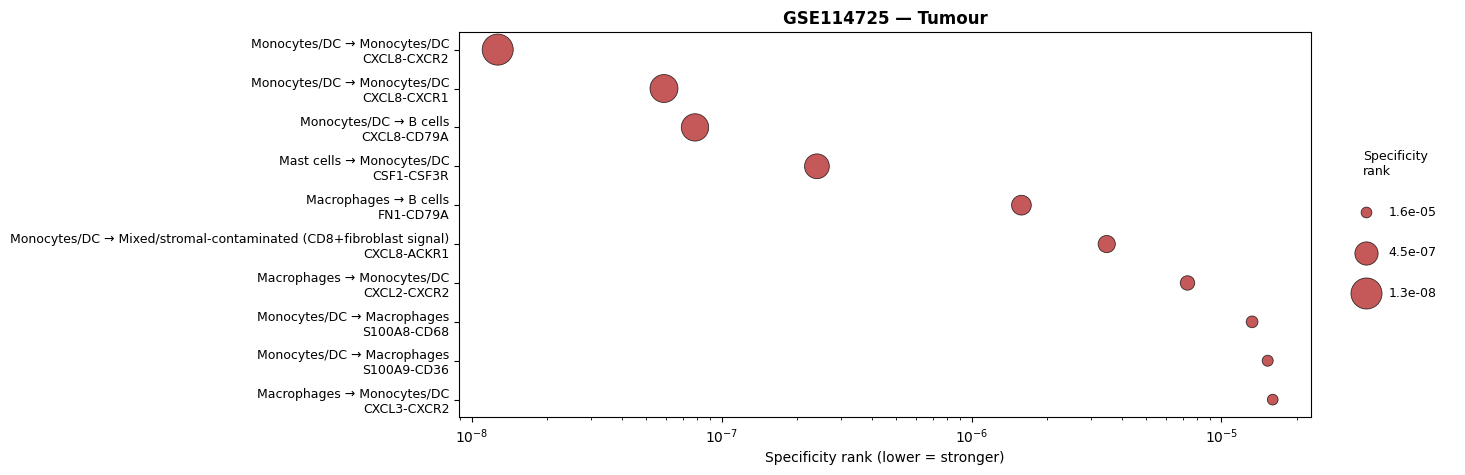

Saved: C:\Users\annam\Dissertation 2026\figures\phase3_liana\GSE114725_liana_dotplot_TUMOR.png — exists on disk: True


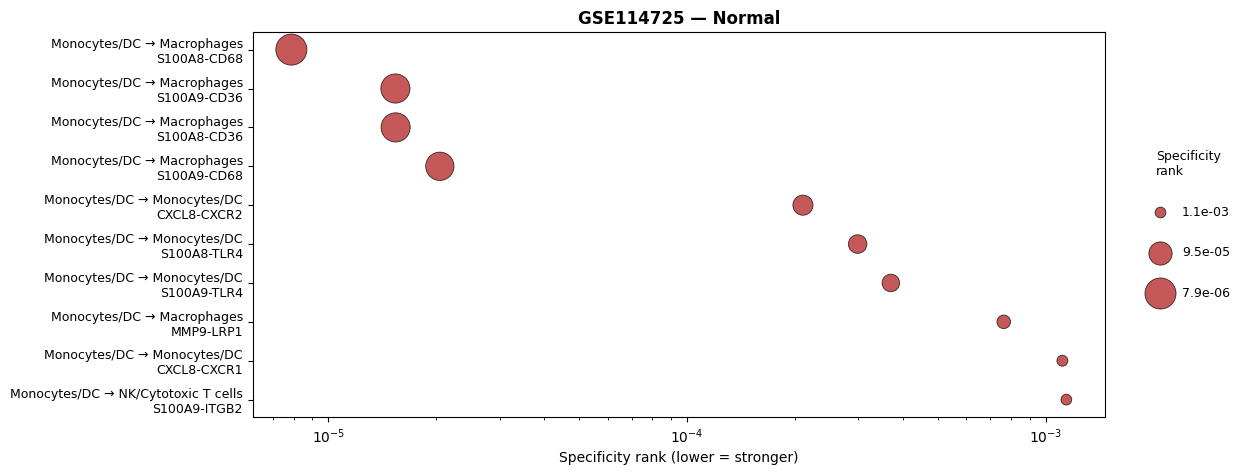

Saved: C:\Users\annam\Dissertation 2026\figures\phase3_liana\GSE114725_liana_dotplot_NORMAL.png — exists on disk: True


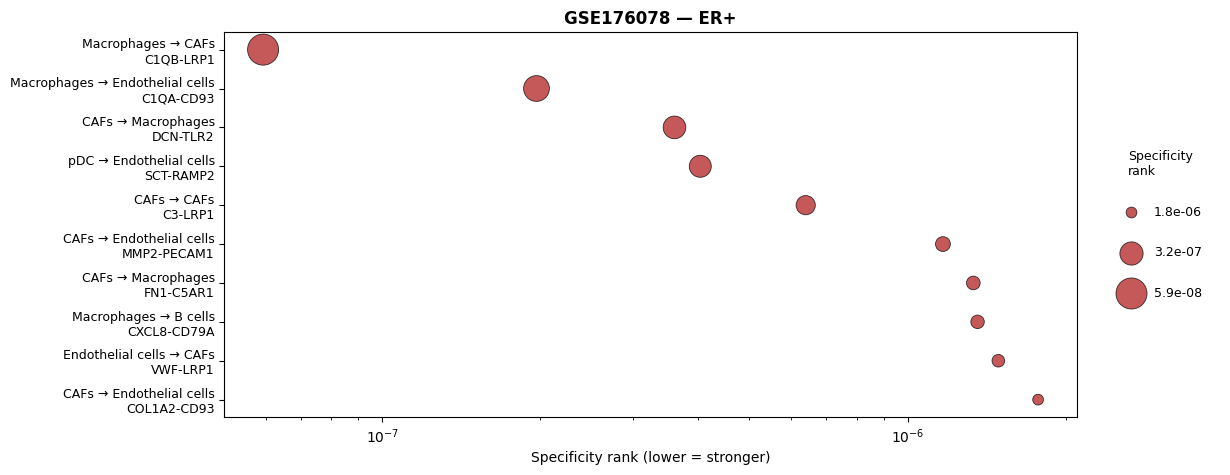

Saved: C:\Users\annam\Dissertation 2026\figures\phase3_liana\GSE176078_liana_dotplot_ERplus.png — exists on disk: True


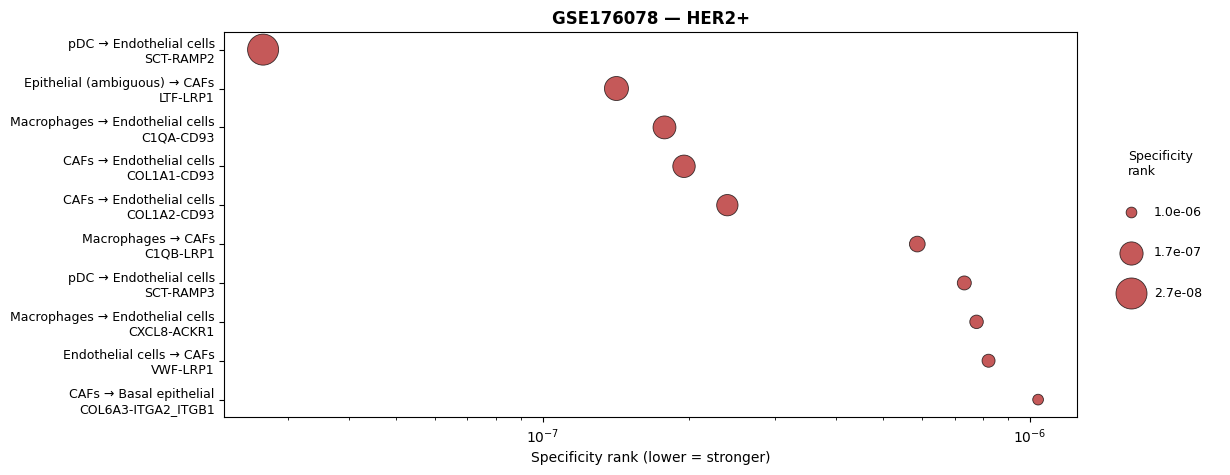

Saved: C:\Users\annam\Dissertation 2026\figures\phase3_liana\GSE176078_liana_dotplot_HER2plus.png — exists on disk: True


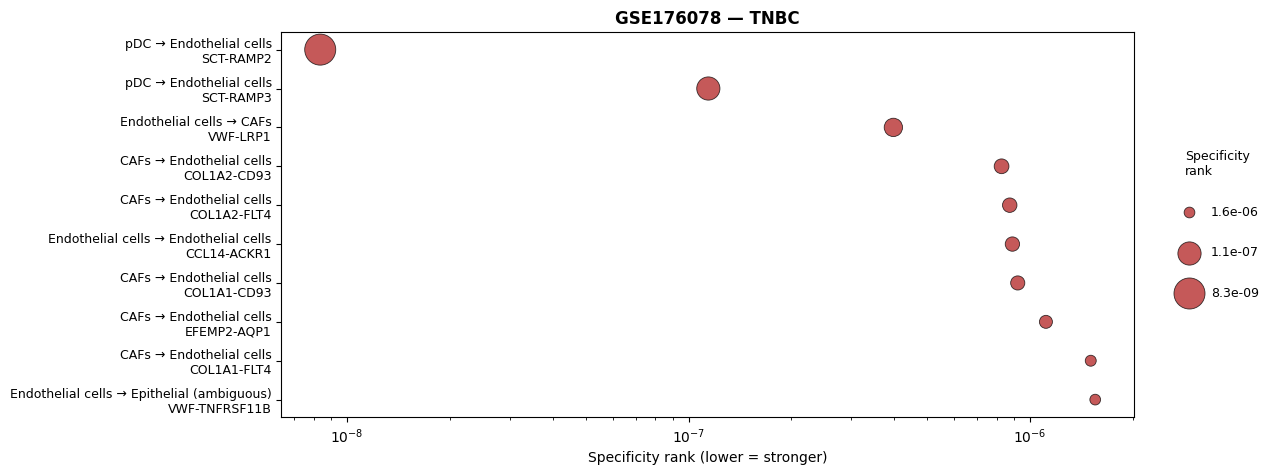

Saved: C:\Users\annam\Dissertation 2026\figures\phase3_liana\GSE176078_liana_dotplot_TNBC.png — exists on disk: True


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
RESULTS_DIR = PROJECT_DIR / "results" / "phase3_liana"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase3_liana"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def plot_liana_dotplot(csv_path, title, save_path, n=10):
    df = pd.read_csv(csv_path)
    top = df.sort_values("specificity_rank").head(n).copy()
    top["interaction"] = (
        top["source"] + " → " + top["target"] + "\n" +
        top["ligand_complex"] + "-" + top["receptor_complex"]
    )
    top["neg_log10_spec"] = -np.log10(top["specificity_rank"])
    top = top.iloc[::-1]

    min_val, max_val = top["neg_log10_spec"].min(), top["neg_log10_spec"].max()
    if max_val > min_val:
        norm = (top["neg_log10_spec"] - min_val) / (max_val - min_val)
    else:
        norm = pd.Series([0.5] * len(top), index=top.index)
    sizes = 60 + norm * 440

    fig, ax = plt.subplots(figsize=(11, max(4, n * 0.5)))
    ax.scatter(
        top["specificity_rank"], range(len(top)),
        s=sizes, c="firebrick", alpha=0.75,
        edgecolors="black", linewidth=0.6
    )
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top["interaction"], fontsize=9)
    ax.set_xscale("log")
    ax.set_xlabel("Specificity rank (lower = stronger)")
    ax.set_title(title, fontsize=12, fontweight="bold")

    legend_ranks_display = [
        top["specificity_rank"].max(),
        np.sqrt(top["specificity_rank"].max() * top["specificity_rank"].min()),
        top["specificity_rank"].min()
    ]
    legend_sizes = [60, 280, 500]
    legend_handles = [
        plt.scatter([], [], s=s, c="firebrick", alpha=0.75,
                     edgecolors="black", linewidth=0.6)
        for s in legend_sizes
    ]
    legend_labels = [f"{r:.1e}" for r in legend_ranks_display]
    ax.legend(
        legend_handles, legend_labels,
        title="Specificity\nrank", loc="center left",
        bbox_to_anchor=(1.02, 0.5), fontsize=9, title_fontsize=9,
        frameon=False, labelspacing=2.2, borderpad=1.5
    )

    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"Saved: {save_path} — exists on disk: {save_path.exists()}")

plot_liana_dotplot(RESULTS_DIR / "GSE114725_liana_TUMOR.csv", "GSE114725 — Tumour", FIGURE_DIR / "GSE114725_liana_dotplot_TUMOR.png")
plot_liana_dotplot(RESULTS_DIR / "GSE114725_liana_NORMAL.csv", "GSE114725 — Normal", FIGURE_DIR / "GSE114725_liana_dotplot_NORMAL.png")
plot_liana_dotplot(RESULTS_DIR / "GSE176078_liana_ERplus.csv", "GSE176078 — ER+", FIGURE_DIR / "GSE176078_liana_dotplot_ERplus.png")
plot_liana_dotplot(RESULTS_DIR / "GSE176078_liana_HER2plus.csv", "GSE176078 — HER2+", FIGURE_DIR / "GSE176078_liana_dotplot_HER2plus.png")
plot_liana_dotplot(RESULTS_DIR / "GSE176078_liana_TNBC.csv", "GSE176078 — TNBC", FIGURE_DIR / "GSE176078_liana_dotplot_TNBC.png")

         ER+  HER2+  TNBC
C1QA    6.71   6.75  4.71
COL1A1  5.65   6.71  6.04
COL1A2  5.75   6.62  6.08
COL4A1  2.69   5.41  5.14
COL4A2  2.86   5.01  4.67


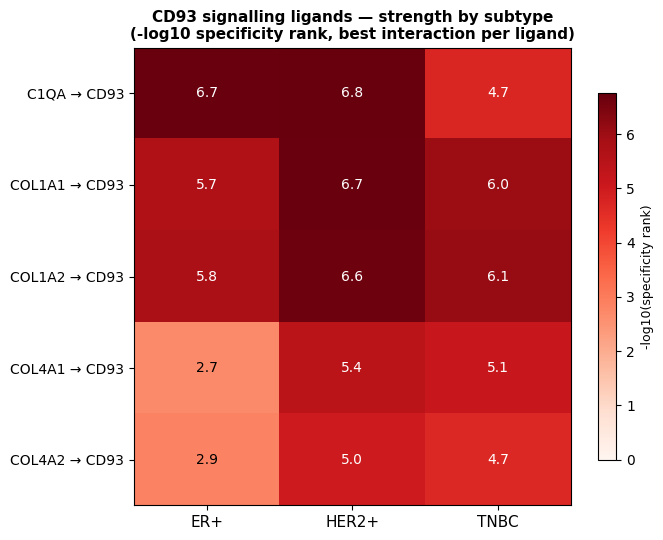


Saved: GSE176078_CD93_signalling_heatmap.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
RES = PROJECT_DIR / "results" / "phase3_liana"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase3_liana"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

subtypes = [("ER+", "ERplus"), ("HER2+", "HER2plus"), ("TNBC", "TNBC")]
top_ligands = ["C1QA", "COL1A1", "COL1A2", "COL4A1", "COL4A2"]  # dominant ligands across all 3

# Build a matrix: rows = ligand, cols = subtype, values = -log10(best specificity_rank for that ligand->CD93)
matrix = pd.DataFrame(index=top_ligands, columns=[s[0] for s in subtypes], dtype=float)

for subtype, fname in subtypes:
    liana = pd.read_csv(RES / f"GSE176078_liana_{fname}.csv")
    cd93 = liana[liana["receptor_complex"] == "CD93"]
    for ligand in top_ligands:
        rows = cd93[cd93["ligand_complex"] == ligand]
        if len(rows) > 0:
            best_rank = rows["specificity_rank"].min()
            matrix.loc[ligand, subtype] = -np.log10(best_rank)
        else:
            matrix.loc[ligand, subtype] = np.nan

print(matrix.round(2))

# ----------------------------
# Heatmap — ligand x subtype, colour = signal strength
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(matrix.values, cmap="Reds", aspect="auto", vmin=0)

ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels(matrix.columns, fontsize=11)
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels([f"{lig} → CD93" for lig in matrix.index], fontsize=10)

# Annotate each cell with the actual value
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        val = matrix.values[i, j]
        if not np.isnan(val):
            text_color = "white" if val > matrix.values.max() * 0.5 else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", color=text_color, fontsize=10)

ax.set_title("CD93 signalling ligands — strength by subtype\n(-log10 specificity rank, best interaction per ligand)",
             fontsize=11, fontweight="bold")
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("-log10(specificity rank)", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE176078_CD93_signalling_heatmap.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("\nSaved: GSE176078_CD93_signalling_heatmap.png")

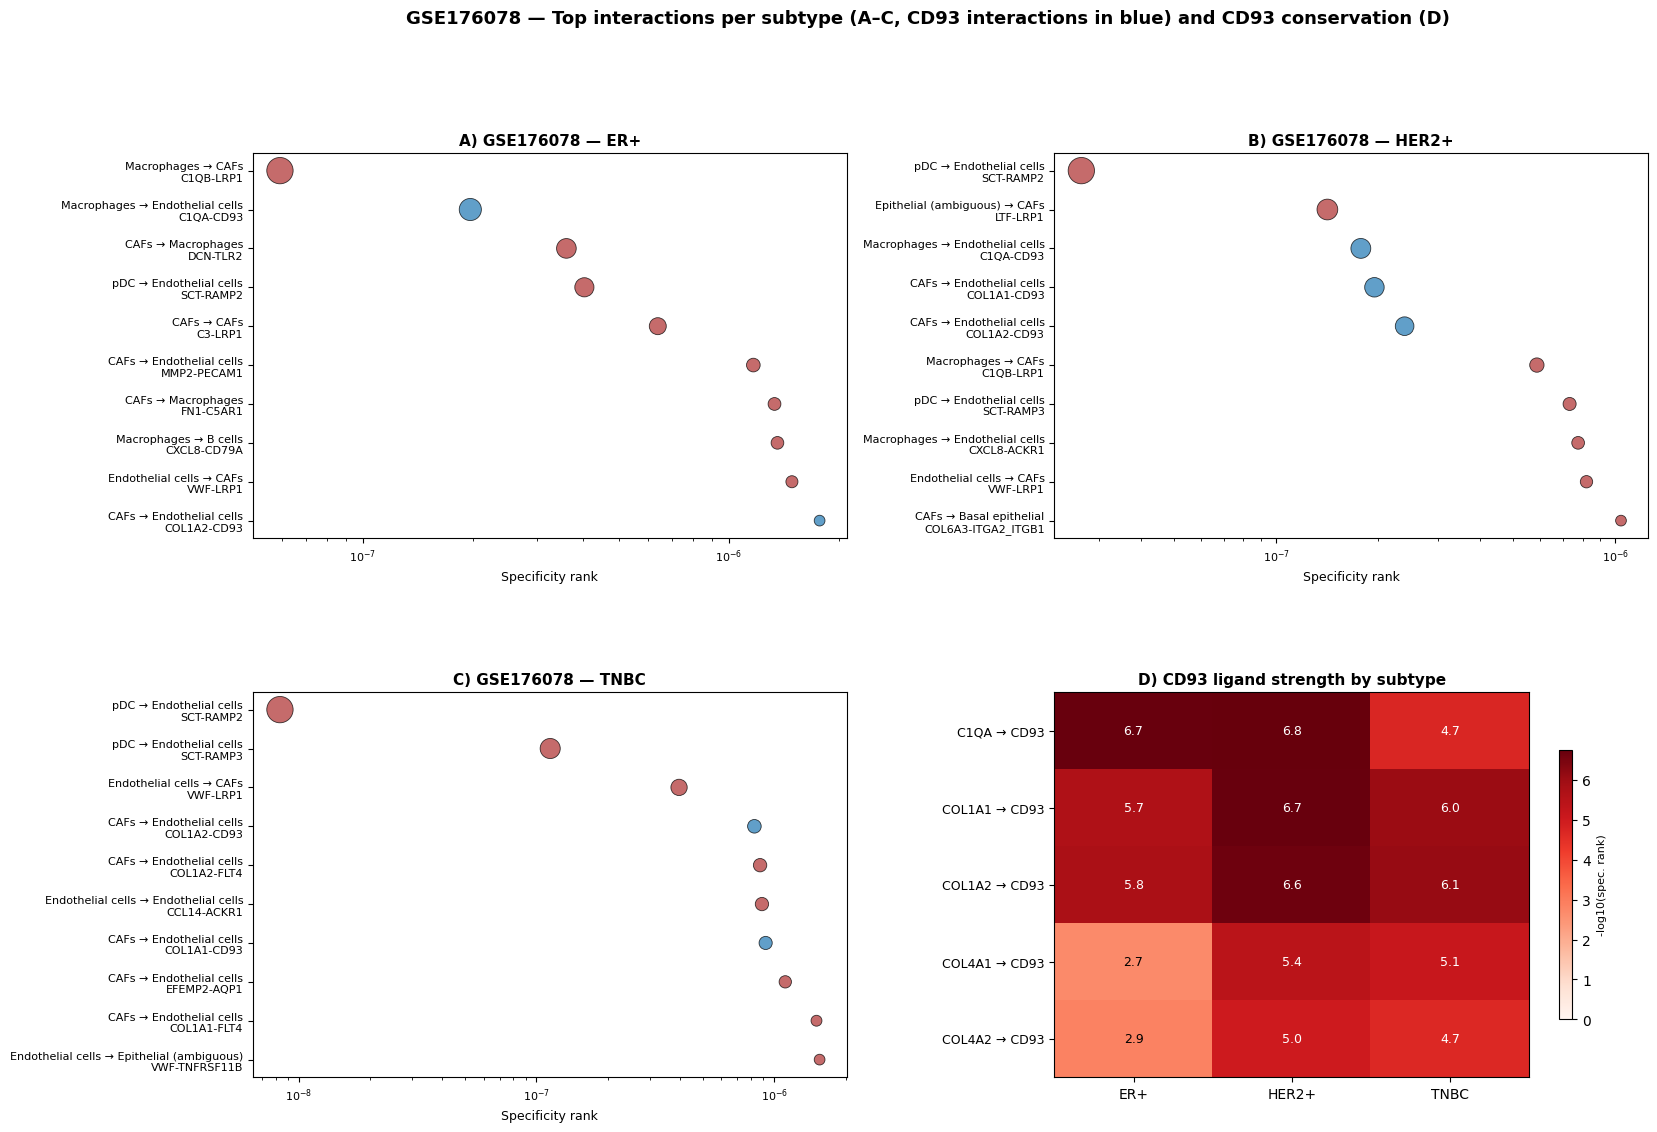

Saved: GSE176078_CD93_multipanel.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
RES = PROJECT_DIR / "results" / "phase3_liana"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase3_liana"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

subtypes = [("ER+", "ERplus"), ("HER2+", "HER2plus"), ("TNBC", "TNBC")]

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35)

# ---- Panels A, B, C: dotplots for each subtype (top-left, top-right, bottom-left) ----
positions = [(0, 0), (0, 1), (1, 0)]
panel_labels = ["A", "B", "C"]

for (subtype, fname), pos, label in zip(subtypes, positions, panel_labels):
    ax = fig.add_subplot(gs[pos])
    df = pd.read_csv(RES / f"GSE176078_liana_{fname}.csv")
    top = df.sort_values("specificity_rank").head(10).copy()
    top["interaction"] = (
        top["source"] + " → " + top["target"] + "\n" +
        top["ligand_complex"] + "-" + top["receptor_complex"]
    )
    top["neg_log10_spec"] = -np.log10(top["specificity_rank"])
    top = top.iloc[::-1]

    min_val, max_val = top["neg_log10_spec"].min(), top["neg_log10_spec"].max()
    norm = (top["neg_log10_spec"] - min_val) / (max_val - min_val) if max_val > min_val else pd.Series([0.5]*len(top), index=top.index)
    sizes = 60 + norm * 300

    # Highlight CD93 interactions in a different colour
    colors = ["#2c7fb8" if "CD93" in i else "#b23a3a" for i in top["ligand_complex"] + "-" + top["receptor_complex"]]
    ax.scatter(top["specificity_rank"], range(len(top)), s=sizes, c=colors, alpha=0.75, edgecolors="black", linewidth=0.6)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top["interaction"], fontsize=8)
    ax.set_xscale("log")
    ax.set_xlabel("Specificity rank", fontsize=9)
    ax.set_title(f"{label}) GSE176078 — {subtype}", fontsize=11, fontweight="bold")
    ax.tick_params(axis="both", labelsize=8)

# ---- Panel D: CD93 heatmap (bottom-right) ----
ax4 = fig.add_subplot(gs[1, 1])
top_ligands = ["C1QA", "COL1A1", "COL1A2", "COL4A1", "COL4A2"]
matrix = pd.DataFrame(index=top_ligands, columns=[s[0] for s in subtypes], dtype=float)
for subtype, fname in subtypes:
    liana = pd.read_csv(RES / f"GSE176078_liana_{fname}.csv")
    cd93 = liana[liana["receptor_complex"] == "CD93"]
    for ligand in top_ligands:
        rows = cd93[cd93["ligand_complex"] == ligand]
        matrix.loc[ligand, subtype] = -np.log10(rows["specificity_rank"].min()) if len(rows) > 0 else np.nan

im = ax4.imshow(matrix.values, cmap="Reds", aspect="auto", vmin=0)
ax4.set_xticks(range(len(matrix.columns)))
ax4.set_xticklabels(matrix.columns, fontsize=10)
ax4.set_yticks(range(len(matrix.index)))
ax4.set_yticklabels([f"{lig} → CD93" for lig in matrix.index], fontsize=9)
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        val = matrix.values[i, j]
        if not np.isnan(val):
            ax4.text(j, i, f"{val:.1f}", ha="center", va="center",
                      color="white" if val > matrix.values.max()*0.5 else "black", fontsize=9)
ax4.set_title("D) CD93 ligand strength by subtype", fontsize=11, fontweight="bold")
cbar = plt.colorbar(im, ax=ax4, shrink=0.7)
cbar.set_label("-log10(spec. rank)", fontsize=8)

fig.suptitle(
    "GSE176078 — Top interactions per subtype (A–C, CD93 interactions in blue) and CD93 conservation (D)",
    fontsize=13, fontweight="bold", y=1.0
)

plt.savefig(FIGURE_DIR / "GSE176078_CD93_multipanel.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: GSE176078_CD93_multipanel.png")